# Deep Learning Project: Titanic Survival Prediction (Classification)
## مقدمة عن المشروع
يهدف هذا المشروع إلى بناء نموذج تعلم عميق (Deep Learning) للتنبؤ بفرص نجاة ركاب سفينة التيتانيك بناءً على بياناتهم الشخصية. تم تنفيذ المتطلبات كاملة من معالجة البيانات، بناء النموذج، التقييم، وحساب الأثر البيئي.

### prepared by:
#### Ahmed Essam Ismail 192100164
#### Mazen Mohsen 192100158
#### Daniel Ehab 192100133
#### Moomen Diaa 191800129

In [16]:
!pip install codecarbon keras-flops

## 1. Data Preprocessing & Cleaning | معالجة البيانات
في هذه المرحلة، قمنا بتنفيذ الخطوات التالية لضمان جودة البيانات:
- **Feature Selection:** حذف الأعمدة غير المؤثرة مثل (Name, Ticket).
- **Data Cleaning (Propagation):** استخدام تقنية الـ Forward & Backward Fill لملء البيانات الناقصة في عمود العمر.
- **Encoding:** تحويل البيانات النصية (ذكر/أنثى) إلى أرقام ليفهمها النموذج.
- **Outliers Removal:** استخدام Z-score لاستبعاد القيم الشاذة.
- **Scaling:** توحيد مقاييس البيانات باستخدام `StandardScaler`.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, matthews_corrcoef
from codecarbon import EmissionsTracker

# 1. قراءة البيانات (تم إضافة مسار التيتانيك هنا)
file_path = '/kaggle/input/competitions/titanic/train.csv' 
df = pd.read_csv(file_path)

# 2. حذف الأعمدة التي لا تفيد في التوقع
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns_to_drop, axis=1)

# 3. تحويل النصوص لأرقام (Encoding) 
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 4. تنظيف البيانات (Data Cleaning & Propagation)
print(f"Missing values BEFORE cleaning:\n{df.isnull().sum().max()}") 
df = df.ffill().bfill() 
print(f"Missing values AFTER cleaning:\n{df.isnull().sum().max()}") 

# 5. تحديد المدخلات (X) والمخرجات (y)
target_column_name = 'Survived' 
X = df.drop(target_column_name, axis=1)
y = df[target_column_name]

# 6. معالجة البيانات: إزالة القيم الشاذة (Outliers) باستخدام Z-score
z_scores = np.abs(stats.zscore(X))
X_clean = X[(z_scores < 3).all(axis=1)]
y_clean = y[X_clean.index]

# 7. تقسيم البيانات لتدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# 8. معالجة البيانات: التقييس (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing is Done! Training shape:", X_train_scaled.shape)

Missing values BEFORE cleaning:
177
Missing values AFTER cleaning:
0
Data Preprocessing is Done! Training shape: (660, 7)


## 2. Model Architecture & Training | بناء وتدريب النموذج
تم بناء شبكة عصبية عميقة (DNN) تتكون من:
- **Input Layer:** تستقبل الخصائص المعالجة.
- **Hidden Layers:** طبقتين بكثافة (32, 16) مع دالة تنشيط `ReLU`.
- **Output Layer:** خلية واحدة مع دالة `Sigmoid` لإخراج احتمالية النجاة.
- **Sustainability:** استخدام مكتبة `CodeCarbon` لتتبع استهلاك الطاقة أثناء التدريب.

In [18]:
# 1. بناء المودل (Deep Learning Model)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ========================================================
# 2. تشغيل متتبع الطاقة والانبعاثات الكربونية
# ========================================================
tracker = EmissionsTracker()
tracker.start()

# تدريب المودل (Train Model)
history = model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=0)

# إيقاف المتتبع وحفظ النتائج
emissions = tracker.stop()

# استخراج استهلاك الطاقة من بيانات المتتبع
energy_consumed = tracker.final_emissions_data.energy_consumed 

#طباعة النتائج
print("=" * 45)
print("Environmental Impact Metrics:")
print("=" * 45)
print(f"Energy Consumption: {energy_consumed:.6f} kWh")
print(f"Carbon Emission:    {emissions:.6f} kg CO2")
print("=" * 45)

# 3. حفظ المودل بصيغة h5
model.save('titanic_model.h5')
print("\n[+] Model successfully saved as 'titanic_model.h5'")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[codecarbon WARNING @ 14:17:32] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:17:32] [setup] RAM Tracking...
[codecarbon INFO @ 14:17:32] [setup] CPU Tracking...
[codecarbon WARNING @ 14:17:32] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:17:32] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:17:32] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.

Environmental Impact Metrics:
Energy Consumption: 0.000322 kWh
Carbon Emission:    0.000045 kg CO2

[+] Model successfully saved as 'titanic_model.h5'


## 3. Learning Curves Analysis | تحليل منحنيات التعلم
في هذا الجزء، نقوم برسم منحنيات التعلم لمراقبة أداء النموذج وتقييم سلوكه أثناء مرحلة التدريب (Training Phase). 
الهدف من هذه المنحنيات هو:
- التأكد من تحسن دقة النموذج (Accuracy) وانخفاض معدل الخطأ (Loss) بمرور الـ Epochs.
- التأكد من عدم حدوث ظاهرة الحفظ الزائد (Overfitting) من خلال مقارنة أداء النموذج على بيانات التدريب (Train) ببيانات التحقق (Validation).

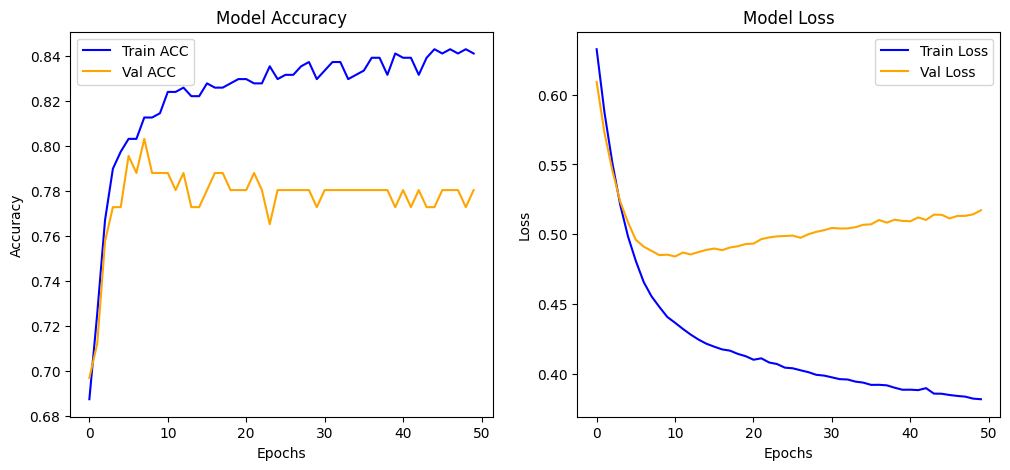

In [19]:
# رسم الـ Learning Curves
plt.figure(figsize=(12, 5))

# منحنى الدقة (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train ACC', color='blue')
plt.plot(history.history['val_accuracy'], label='Val ACC', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# منحنى الخسارة (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## 4. Results & Sustainability Report | النتائج وتقارير الكفاءة
في هذا الجزء، يتم عرض النتائج النهائية للاختبار (Test Set) بناءً على المقاييس المطلوبة:
- **Performance Metrics:** (Accuracy, F1-Score, ROCAUC, etc.)
- **Computational Efficiency:** حساب الـ **FLOPS** لقياس تعقيد العمليات الحسابية.
- **Environmental Impact:** تقرير استهلاك الطاقة وانبعاثات الكربون.

In [22]:
# 6. اختبار المودل
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# طباعة مقاييس التقييم كاملة (Classification Metrics)
print("-" * 30)
print("Evaluation Metrics:")
print("-" * 30)
print(f"ROC AUC:    {roc_auc_score(y_test, y_pred_probs):.4f}")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_classes):.4f}")
print(f"F1 Score:   {f1_score(y_test, y_pred_classes):.4f}")
print(f"Kappa:      {cohen_kappa_score(y_test, y_pred_classes):.4f}")
print(f"MCC:        {matthews_corrcoef(y_test, y_pred_classes):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred_classes):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_classes):.4f}")
print("-" * 30)

# حساب الـ FLOPS برمجياً باستخدام أوزان الطبقات (طريقة مضمونة لكل الإصدارات)
def calculate_flops(keras_model):
    total_flops = 0
    for layer in keras_model.layers:
        if isinstance(layer, tf.keras.layers.Dense):
            weights = layer.get_weights()
            if len(weights) > 0: # التأكد إن الطبقة تم بناؤها ولها أوزان
                # weights[0] هي مصفوفة الأوزان (Input_dim x Output_dim)
                input_dim = weights[0].shape[0]
                output_dim = weights[0].shape[1]
                
                # كل خلية بتعمل عملية ضرب وجمع (2 FLOPS) زائد الـ Bias
                layer_flops = 2 * input_dim * output_dim + output_dim
                total_flops += layer_flops
    return total_flops

flops_count = calculate_flops(model)
print(f"FLOPS (Calculated): {flops_count} operations")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
------------------------------
Evaluation Metrics:
------------------------------
ROC AUC:    0.9197
Accuracy:   0.8788
F1 Score:   0.8438
Kappa:      0.7449
MCC:        0.7459
Recall:     0.8182
Precision:  0.8710
------------------------------
FLOPS (Calculated): 1553 operations
